# Phosphorus analysis

We analyze the effect of fertilizer on maize crop yield using the Double Machine Learning method (DML). Under the DML structural equation model, and being treatment a continuous variable, the effect of fertilizer is functionally equivalent to the fertilizer Agronomic Efficiency (AE). We will address the question **what is the effect of P fertilizer on maize yield** considering the next effect modifier factors:
- Soil type, i.e. sandy or non-sandy.
- Fertilizer amount itself, i.e. the fertilizer response curve.
- Having a history of maize-legume rotation

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
plt.style.use('../publication.mplstyle') # mpl style for publication-quality figures
# Modify cycler palette
plt.rcParams['axes.prop_cycle'] = mpl.cycler(
    'color', ('#E66100', '#5D3A9B', '#E1BE6A', '#40B0A6', '#1A85FF', '#D41159')
)  

import pickle
import geopandas as gpd

In [2]:
from CAgsalML.tuning import GPOptimizer
from CAgsalML.transformers import SpatialTransform

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  r2_score
from sklearn.model_selection import  cross_val_predict
from skopt.space import Categorical, Integer, Real

In [4]:
RANDOM_SEED = 43
np.random.seed(RANDOM_SEED)
import random
random.seed(RANDOM_SEED)

# Adjust data

In [5]:
DATA_VERSION = '260116'
DATA_PATH = "/data/mba-tza"
data = pd.read_pickle(f'{DATA_PATH}/processed/data-dag-{DATA_VERSION}.pkl')
data = data.loc[data.crop_maize]  # Focus on maize only
adjustment_nodes = [
    # Minimal optimal adjustment set
    'otherManagement', 'fertilizerAmountN', 'fieldHistory', 'weatherSeason',
    'variety', 'fertilizerTiming','soil'
]
columns_dict = { # Includes all nodes, not only adjustment nodes
    'fertilizerAmountP': ['fertP_total'],
    'fertilizerAmountN': ['fertN_total'],
    'fieldHistory': [
        'fieldsize_value',  'history_maize', 'history_nocrop', 'history_legume',
        'history_rootandtuber', 'history_oilseed', 'history_maizelegume'
    ],
    'soil': [
        'soilfert_cec', 'soilfert_oc', 'soilpp_clay',
        'soilpp_density', 'soilpp_sand', 'soil_sandy'
    ],
    'outcome': ['outcome_prodstd'],
    'fertilizerTiming': [
        'fertN_56leaves', 'fertN_810leaves', 'fertN_basal', 
        'fertN_kneehigh','fertN_tasselingsilking', 'fertP_56leaves',
        'fertP_810leaves', 'fertP_basal', 'fertP_kneehigh',
        'fertP_tasselingsilking'
    ],
    'otherManagement': [
       'herbicide_post', 'herbicide_pre', 'herbicide_any', 'manure_any',
       'planting_handhoe', 'planting_ploughsowing', 'planting_string',
       'residue_burn', 'residue_feedtoanimals', 'residue_incorporateinthesoil',
       'residue_leaveonfield', 'residue_onfield'
    ],
    'variety': ['variety_hybrid', 'variety_recycled'],
    'accessibilityRAI': ['accessibility_rai'],
    'investmentCap': ['investing_capacity_index'],
    'weatherSeason': [
        '0to10perc_season_tmean', '0to10perc_season_srad',
        '0to10perc_season_prec', '0to10perc_season_rainydays',
        '10to20perc_season_tmean', '10to20perc_season_srad',
        '10to20perc_season_prec', '10to20perc_season_rainydays',
        '20to30perc_season_tmean', '20to30perc_season_srad',
        '20to30perc_season_prec', '20to30perc_season_rainydays',
        '30to40perc_season_tmean', '30to40perc_season_srad',
        '30to40perc_season_prec', '30to40perc_season_rainydays',
        '40to50perc_season_tmean', '40to50perc_season_srad',
        '40to50perc_season_prec', '40to50perc_season_rainydays',
        '50to60perc_season_tmean', '50to60perc_season_srad',
        '50to60perc_season_prec', '50to60perc_season_rainydays',
        '60to70perc_season_tmean', '60to70perc_season_srad',
        '60to70perc_season_prec', '60to70perc_season_rainydays',
        '70to80perc_season_tmean', '70to80perc_season_srad',
        '70to80perc_season_prec', '70to80perc_season_rainydays',
        '80to90perc_season_tmean', '80to90perc_season_srad',
        '80to90perc_season_prec', '80to90perc_season_rainydays',
        '90to100perc_season_tmean', '90to100perc_season_srad',
        '90to100perc_season_prec', '90to100perc_season_rainydays',
        '0to100perc_season_tmean', '0to100perc_season_srad',
        '0to100perc_season_prec', '0to100perc_season_rainydays',
    ]
}
assert all(i in columns_dict for i in adjustment_nodes)
outcome_name = 'outcome_prodkgha'
treatment_name = 'fertP_total'
# Bad controls. All nodes that are not in the adjustment set.
bad_controls = [
    i for c in sorted(set(columns_dict) - set(adjustment_nodes)) 
    for i in columns_dict[c]
]
features = [i for v in columns_dict.values() for i in v]
features = list(sorted(
    list(set(features) - set(bad_controls) - {outcome_name, treatment_name})
))

# Import geometries.
crs = 'EPSG:32736'
points = gpd.read_file(f'{DATA_PATH}/geo/points.geojson')
points = points.set_index('fieldID')[['geometry']]
points = points.loc[data.index]
points = points.to_crs(crs)
admin = gpd.read_file(f'{DATA_PATH}/geo/tza_shp/tza_admbnda_adm3_20181019.shp')
admin = admin.to_crs(crs)

# Perform a spatial join to assign ADM3_PCODE and ADM2_PCODE to each point
points = gpd.sjoin(
    points, admin[['ADM3_PCODE', 'ADM2_PCODE', 'geometry']], 
    how="left", predicate="within"
)
points = points.drop(columns=['index_right'])
# There is only a few points there, then I'll move then to the neighboring unit
points['ADM2_PCODE'] = points['ADM2_PCODE'].replace({'TZ2610': 'TZ2609'}) 

# This is the data before transforming it for DAG, just in case
clean_data = pd.read_pickle(f'{DATA_PATH}/processed/maize-soya-clean-{DATA_VERSION}.pkl')

# Get indexes for the subset of data we are interested in. We will use all data, 
# this is defined just in case. 
index_zone_subset = data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

In [6]:
# Assign to 0 all the stage-specific fertilizer amounts if the total is zero
data.loc[data.fertP_total == 0, data.filter(like='fertP').columns] = 0
data.loc[data.fertN_total == 0, data.filter(like='fertN').columns] = 0
data = data.loc[data.fertP_total > 0]

In [7]:
TIMINGS = [ # We don't include emergence, as it will be merged to basal
    'basal', 'kneehigh', '56leaves', '810leaves',
    'tasselingsilking'
]
# Check the variability of amounts.
data.loc[:, [f'fertP_{t}' for t in TIMINGS]].describe()

,fertP_basal,fertP_kneehigh,fertP_56leaves,fertP_810leaves,fertP_tasselingsilking
count,1041.000000,1036.000000,1036.000000,1036.000000,1036.000000
mean,0.764563,0.011837,0.178368,0.041997,0.004371
std,0.410290,0.100443,0.371271,0.176290,0.056242
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.547619,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
T_series = data[treatment_name]
Y_series = data[outcome_name]

transformed_data = pd.DataFrame(index=data.index)
# Normalize features
numeric_features = list(data[features].select_dtypes(include='number').columns)
numeric_features = list(sorted(set(numeric_features).intersection(features)))
dummy_features = set((data.loc[:, data.isin([0, 1]).all()].columns))
dummy_features = dummy_features - set(numeric_features)
dummy_features = list(sorted(dummy_features.intersection(features)))
timing_features = [f'fertP_{t}' for t in TIMINGS[:]]

numeric_features = list(sorted(
    (set(numeric_features) - set(dummy_features)) - set(timing_features)
))

transformed_data[numeric_features] = StandardScaler().fit_transform(
    data[numeric_features]
).astype(np.float32)
transformed_data[dummy_features] = data[dummy_features].astype(float)
transformed_data[timing_features] = data[timing_features]

# Select only features and Drop those rows with no outcome
transformed_data = transformed_data[features]
transformed_data = transformed_data.loc[data[outcome_name].dropna().index]

# Drop rows with values not within a feasible range
NORMALIZED_LIM = 5
transformed_data = transformed_data.loc[
    (transformed_data < NORMALIZED_LIM).all(axis=1) & 
    (transformed_data > -NORMALIZED_LIM).all(axis=1)
]
# Redefine index of samples
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]
transformed_data.shape

(974, 82)

## Spatial demeaning of outcome and treatment

In [9]:
# The DML pipeline includes a demeaning step, then the nuisance functions
# will predict the demeaned variable. Thus, the spatially demeaned outcomes and 
# treatments will be used to select the ML models.

# Spatially demean the outcome
spatial_transformer_yield = SpatialTransform(
    points.geometry, maxlag=50e3, esitmator='cressie',
    model='matern', n_lags=50, use_nugget=True
)
spatial_transformer_yield.fit(data.loc[transformed_data.index, outcome_name])
demeaned_outcome = pd.Series(
    spatial_transformer_yield.transform_demean(), index=transformed_data.index
)
# Spatially demean the treatment
spatial_trans_index = points.index
spatial_transformer_fertilizer = SpatialTransform(
    points.geometry, maxlag=50e3, esitmator='cressie',
    model='matern', n_lags=50, use_nugget=True
)
spatial_transformer_fertilizer.fit(data.loc[transformed_data.index, treatment_name])
demeaned_treatment = pd.Series(
    spatial_transformer_fertilizer.transform_demean(), index=transformed_data.index
)
nona_t_and_y_index = demeaned_treatment.dropna().index.intersection(demeaned_outcome.dropna().index)
demeaned_treatment = demeaned_treatment.loc[nona_t_and_y_index]
demeaned_outcome = demeaned_outcome.loc[nona_t_and_y_index]

In [10]:
# Keep only complete records
transformed_data = transformed_data.dropna()
transformed_data = transformed_data.loc[nona_t_and_y_index]
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]
transformed_data.shape

(961, 82)

## Group indicators

### Timing indicators

In [11]:
appl_clusters_df = pd.DataFrame(transformed_data[timing_features], columns=timing_features)

In [12]:
def assign_timing_strategy(row):
        basal = False
        n_tops = 0
        basal = row['fertP_basal'] > 0
        n_tops = (row[['fertP_kneehigh', 'fertP_56leaves', 'fertP_810leaves', 'fertP_tasselingsilking']] > 0).sum()
        if not basal:
            return "Top-Only"
        # elif n_tops < 1:
        #     return "Only Basal"
        else:
            # return "Basal+Top"
            return "Basal-Only"

appl_clusters_df["Cluster name"] = appl_clusters_df.apply(assign_timing_strategy, axis=1)

In [13]:
# How many samples where a single application timing was used
(appl_clusters_df.iloc[:, :5] > .99).any(axis=1).sum()

np.int64(895)

In [14]:
appl_clusters_df['Cluster name'].value_counts()

Cluster name
Basal-Only    759
Top-Only      202
Name: count, dtype: int64

## Add the group-indicators variables
The group indicator variables for timing cluster, and P-fertilizer type are added to the data 

In [15]:
# Add the timing dummies and p-fertilizer dummies to the data. Note that the noise dummy is not added
timing_dummies = pd.get_dummies(appl_clusters_df['Cluster name'], prefix='timing', drop_first=False).astype(int)
transformed_data = pd.concat([transformed_data, timing_dummies], axis=1)
features.extend(timing_dummies.columns)
# Legume dummies are not added as they have the same exact information as history_legume

In [16]:
transformed_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
0to100perc_season_prec,961.0,0.005442,0.944283,-2.830554,-0.647199,0.003857,0.683673,3.051744
0to100perc_season_rainydays,961.0,0.012214,0.930614,-2.930614,-0.596238,0.184230,0.663065,2.204338
0to100perc_season_srad,961.0,0.011702,1.001876,-3.369371,-0.468577,0.175787,0.635964,2.478285
0to100perc_season_tmean,961.0,-0.027411,0.932285,-4.046594,-0.673806,-0.045610,0.521640,3.612816
0to10perc_season_prec,961.0,0.002007,0.992582,-2.319004,-0.776855,-0.009547,0.614428,4.840126
...,...,...,...,...,...,...,...,...
soilpp_sand,961.0,-0.010963,0.996761,-2.250624,-0.724242,-0.241210,0.512320,3.313908
variety_hybrid,961.0,0.042664,0.202203,0.000000,0.000000,0.000000,0.000000,1.000000
variety_recycled,961.0,0.072841,0.260010,0.000000,0.000000,0.000000,0.000000,1.000000
timing_Basal-Only,961.0,0.789802,0.407661,0.000000,1.000000,1.000000,1.000000,1.000000


# Effect estimation pipeline

## Generalized propensity score

In [17]:
x_names = list(timing_dummies.columns)
w_names = list(sorted(set(features) - set(x_names)))

# training_idxs, testing_idxs = train_test_split(index_zone_subset, random_state=RANDOM_SEED, train_size=1)
testing_idxs = [] 
training_idxs = index_zone_subset # Use all for training and rely on CV 
print(f"{len(training_idxs)} training samples")
print(f"{len(testing_idxs)} testing samples")
print(f'N features: {len(x_names)+len(w_names)}')

961 training samples
0 testing samples
N features: 84


In [18]:
# First we need a model for the treatment
X_train = transformed_data.loc[training_idxs, w_names + x_names]
t_train = demeaned_treatment.loc[training_idxs]

optimizer_treatment = GPOptimizer(
    model=RandomForestRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=10),
        max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        n_estimators=100, random_state=RANDOM_SEED
    )
)

model_treatment, cv_scores_treatment = optimizer_treatment.cv_optimize(
    X_train, t_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=50, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)
print(f"Best hyperparameters for treatment model:\n{model_treatment}")
print(f"R2 = {np.mean(cv_scores_treatment):.4f} (+/- {np.std(cv_scores_treatment):.4f})")

Best hyperparameters for treatment model:
RandomForestRegressor(max_depth=np.int64(10), max_features=np.str_('sqrt'),
                      min_samples_leaf=np.int64(4), random_state=43)
R2 = 0.1667 (+/- 0.0660)


In [19]:
model_treatment = model_treatment.fit(X_train, t_train)
pd.Series(
    model_treatment.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

fertN_total               0.145793
fieldsize_value           0.051924
fertN_basal               0.040846
fertP_810leaves           0.040402
fertP_basal               0.031279
0to100perc_season_srad    0.025313
70to80perc_season_srad    0.023562
10to20perc_season_srad    0.022077
0to10perc_season_srad     0.021575
soilpp_clay               0.020954
dtype: float64

<Axes: ylabel='Count'>

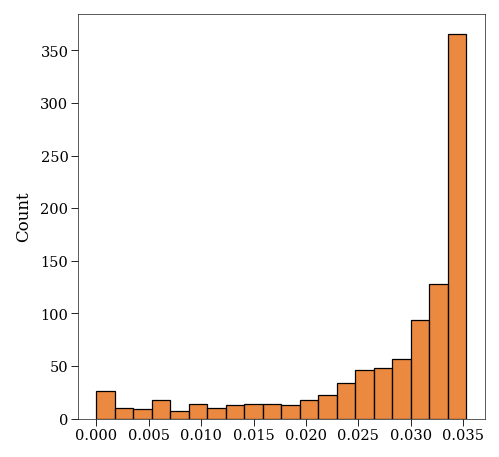

In [20]:
from scipy import stats
# Use Zhu et al. (2018) and Hirano and Gimbens (2004) approach to estimate PS for continuous treatments
T = demeaned_treatment.values
# Get the CV predictions to estimate the variance of residuals
T_pred = cross_val_predict(
    model_treatment, 
    X=transformed_data.loc[:, w_names + x_names],
    y=demeaned_treatment,
)
T_res = T - T_pred
res_var = np.var(T_res)

# Estimate the GPS
# gps = (1/(np.sqrt(2*np.pi*res_var)))*np.exp((-1/(2*res_var))*treatment_res**2)
gps_density = stats.norm.pdf(
    T, 
    loc=T_pred, 
    scale=res_var**.5 # Scale is sd in this function
)
sns.histplot(gps_density)

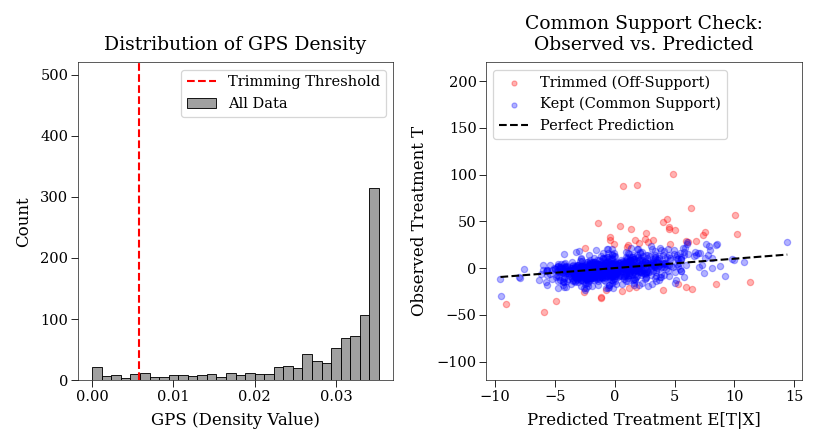

In [21]:
threshold = np.quantile(gps_density, 0.05)
mask_support = gps_density >= threshold
fig, axes = plt.subplots(1, 2, figsize=(5.5, 3))
ax = axes[0]

sns.histplot(gps_density, bins=30, ax=axes[0], color='grey', label='All Data')
ax.axvline(threshold, color='red', linestyle='--', label='Trimming Threshold')
ax.set_title("Distribution of GPS Density")
ax.set_xlabel("GPS (Density Value)")
ax.legend()
ax.set_ylim(0, 520)

ax = axes[1]
ax.scatter(T_pred[~mask_support], T[~mask_support], alpha=0.3, color='red', label='Trimmed (Off-Support)')
ax.scatter(T_pred[mask_support], T[mask_support], alpha=0.3, color='blue', label='Kept (Common Support)')
ax.plot([min(T_pred), max(T_pred)], [min(T_pred), max(T_pred)], 'k--', lw=1, label='Perfect Prediction')

ax.set_title("Common Support Check:\nObserved vs. Predicted")
ax.set_xlabel("Predicted Treatment E[T|X]")
ax.set_ylabel("Observed Treatment T")
ax.legend(loc='upper left', facecolor='none')
ax.set_ylim(-120, 220)
# ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
fig.savefig(f'{DATA_PATH}/results/figures/P-fertilizer-gps-support.pdf', bbox_inches='tight', dpi=300)

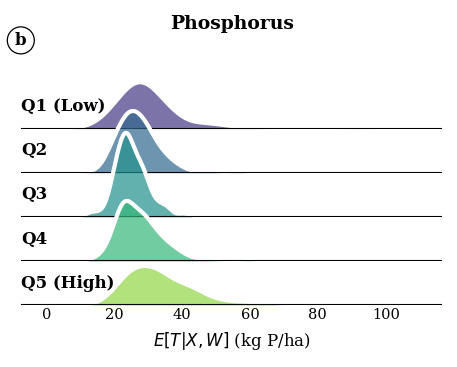

In [22]:
spatial_t = spatial_transformer_fertilizer.predict()
spatial_t = spatial_t[~np.isnan(spatial_t)] 
ps_df = pd.DataFrame({
    'T_pred': (T_pred + spatial_t)[mask_support], 
    'Strata': pd.qcut(T[mask_support], 5, labels=False)
}, index=transformed_data.iloc[mask_support].index)
ps_df = ps_df.loc[ps_df.T_pred < 100]

g = sns.FacetGrid(ps_df, row="Strata", hue="Strata", aspect=7, height=.5, palette="viridis")
g.map(sns.kdeplot, "T_pred", clip_on=False, fill=True, alpha=0.7, lw=0)
g.map(sns.kdeplot, "T_pred", clip_on=False, color="w", lw=2)

g.fig.subplots_adjust(hspace=-.5)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
g.axes.flat[0].set_title("Phosphorus", fontweight='bold', y=.99) 
g.axes.flat[-1].set_xlabel(r'$E[T|X,W]$'+' (kg P/ha)')

# Optional: Add text labels for each stratum
for ax, label in zip(g.axes.flat, ["Q1 (Low)", "Q2", "Q3", "Q4", "Q5 (High)"]):
    ax.text(0, 0.2, label, fontweight="bold", transform=ax.transAxes)
    ax.axhline(0, color='k', linestyle="-")
    ax.set_facecolor('none')
    # ax.grid(None)
    ax.tick_params(length=0)

g.axes.flat[0].text(
    0, 1, 'b', transform=g.axes.flat[0].transAxes, va='center', ha='center', fontsize=8,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
)


g.fig.savefig(f'{DATA_PATH}/results/figures/P-fertilizer-gps-support-strata.pdf', bbox_inches='tight', dpi=300)

In [23]:
# Trim extreme GPS values 
transformed_data_pstrimmed = transformed_data.copy()
transformed_data_pstrimmed = transformed_data_pstrimmed.loc[gps_density > threshold]

In [24]:
# Select the new subset of the data after PS-trimming
index_zone_subset = transformed_data_pstrimmed.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]
transformed_data_pstrimmed.shape

(912, 84)

## Outcome model $q(X, W)$

In [25]:
# Re-select the training indexes based on the new subset from PS-trimming. 
training_idxs = training_idxs.intersection(index_zone_subset)
# testing_idxs = testing_idxs.intersection(index_zone_subset)
X_train = transformed_data_pstrimmed.loc[:, w_names + x_names]
t_train = demeaned_treatment.loc[training_idxs]
T = demeaned_treatment.loc[training_idxs].values

In [26]:
y_train = demeaned_outcome.loc[training_idxs]

optimizer_q = GPOptimizer(
    model=RandomForestRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=10),
        max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        n_estimators=100, random_state=RANDOM_SEED
    )
)

model_q, cv_scores_q = optimizer_q.cv_optimize(
    X_train, y_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=100, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)
print(f"Best hyperparameters for outcome model:\n{model_q}")
print(f"R2 = {np.mean(cv_scores_q):.4f} (+/- {np.std(cv_scores_q):.4f})")

Best hyperparameters for outcome model:
RandomForestRegressor(max_depth=np.int64(5), max_features=np.str_('sqrt'),
                      min_samples_leaf=np.int64(17), random_state=43)
R2 = 0.0444 (+/- 0.0255)


In [27]:
model_q = model_q.fit(X_train, y_train)

In [28]:
pd.Series(
    model_q.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

fertN_total                 0.185285
fieldsize_value             0.080745
20to30perc_season_srad      0.030586
0to10perc_season_srad       0.029737
90to100perc_season_srad     0.023385
0to10perc_season_tmean      0.022587
60to70perc_season_prec      0.022155
0to100perc_season_srad      0.022051
80to90perc_season_prec      0.021655
90to100perc_season_tmean    0.021364
dtype: float64

## Effect estimation with DML 

In [29]:
from econml.dml import LinearDML
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures, add_dummy_feature
from sklearn.multioutput import MultiOutputRegressor

In [30]:
sandy_series = transformed_data_pstrimmed['soil_sandy'].to_numpy()
sandy_series.mean()

### Effect only Soil

In [31]:
# Homogeneous effect: Response curve is a line and it does not depend on timing
X_soil = np.vstack([~sandy_series.astype(bool), sandy_series]).T

dml_soil_features = list(filter(
    lambda x: not x.startswith('timing'),
    features
))
W_soil = transformed_data_pstrimmed.loc[:, dml_soil_features]
Y = demeaned_outcome.loc[transformed_data_pstrimmed.index].to_numpy()
T = demeaned_treatment.loc[transformed_data_pstrimmed.index].to_numpy()

lineardml_only_soil = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED, 
    fit_cate_intercept=False,
)
lineardml_only_soil = lineardml_only_soil.fit(
    Y=Y, T=T, W=W_soil, X=X_soil,
    inference='statsmodels', cache_values=True,
)
x_names_soil = ['Non-sandy', 'Sandy']
lineardml_only_soil.summary(feature_names=x_names_soil)

CATE Intercept Results:  No intercept was fitted!


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
Non-sandy,52.505,7.835,6.702,0.0,37.149,67.86
Sandy,53.888,11.649,4.626,0.0,31.057,76.719


### Effect Soil + Variable rate

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
cubic_spline_transformer = SplineTransformer(
    degree=3, n_knots=4, include_bias=True,
    knots='uniform',
)

# Transform the absolute T, and fit one Spatial Transformer for each component
# of the transformed T.
T_absolute = data.loc[transformed_data_pstrimmed.index, treatment_name].to_numpy()
T_trans = cubic_spline_transformer.fit_transform(T_absolute.reshape(-1, 1))
T_spline_spatial_avg = np.zeros_like(T_trans) # Spatial average vector for the Transformed treatment
for i in range(T_trans.ndim):
    t_col = T_trans[:, i]
    spatial_transformer = SpatialTransform(
        points.geometry, maxlag=50e3, esitmator='cressie',
        model='matern', n_lags=50, use_nugget=True
    )
    spatial_transformer.fit(t_col)
    t_trans_col = spatial_transformer.transform_demean() 
    T_spline_spatial_avg[:, i] = t_col - np.where(np.isnan(t_trans_col), 0, t_trans_col)

def spatial_anomaly_transform(t):
    return t - T_spline_spatial_avg

spatial_anomaly_transformer = FunctionTransformer(spatial_anomaly_transform)
treatment_featurizer = Pipeline([
    ('spline', cubic_spline_transformer),
    ('spatial anomaly', spatial_anomaly_transformer)
])

In [33]:
# Amount heterogeneous: response is a curve and it does not depend on timing
lineardml_soil_rate = LinearDML(
    model_y=model_q, 
    model_t=MultiOutputRegressor(model_treatment), 
    treatment_featurizer=treatment_featurizer,
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False, 
)
lineardml_soil_rate = lineardml_soil_rate.fit(
    Y=Y, T=T_absolute.reshape(-1, 1), W=W_soil, X=X_soil,
    inference='statsmodels', cache_values=True,
)

In [34]:
spatial_y = pd.Series( # Vector of spatial average for Y.
    spatial_transformer_yield.predict(), index=spatial_trans_index
).loc[index_zone_subset].to_numpy()


T0 = T_absolute.mean() # Reference or base fertilizer amount
def rate_inference(X, est=lineardml_soil_rate, T0=T0, T1=100, y_offset=0, scale=1):
    """
    Function to make inference on the fitted estimator. We do this because the inference
    in the original object struggles with the spatial transformation when a subset of 
    the data is used
    """
    param_cov_matrix = est._ortho_learner_model_final._model_final._model._param_var
    param = est._ortho_learner_model_final._model_final._model._param
    t_change = cubic_spline_transformer.transform([[T1]]) - cubic_spline_transformer.transform([[T0]])
    x_final_model = []
    for j in range(t_change.shape[1]):
        # For each element in t_change, multiply it with both columns of X_sand
        x_final_model.append(X * t_change[0, j])
    x_final_model = np.hstack(x_final_model)

    ate = (x_final_model.mean(axis=0).reshape(1, -1) @ param.reshape(-1, 1))[0, 0]
    ate_se = np.sqrt(
        x_final_model.mean(axis=0).reshape(1, -1) @ 
        param_cov_matrix @ 
        x_final_model.mean(axis=0).reshape(-1, 1)
    )[0, 0]

    # Calculate confidence interval
    ci_mean_lower = ate - 1.96 * ate_se
    ci_mean_upper = ate + 1.96 * ate_se

    # Calculate p-value
    if ate_se != 0:
        t_stat = ate / ate_se
        p_value = 2 * stats.norm.sf(np.abs(t_stat))
    else:
        p_value = np.nan # Or 1.0 if se is 0 and ate is also 0

    return {
        'mean_point': ate/scale, 
        'stderr_mean': ate_se/scale,
        'ci_mean_lower': ci_mean_lower/scale,
        'ci_mean_upper': ci_mean_upper/scale,
        'pvalue': p_value
    }

In [35]:
ate_df = pd.DataFrame(
    columns=['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue'], 
    index=pd.MultiIndex(names=('Estimate', 'Soil'), levels=[[], []], codes=[[], []])
)
t25, t75 = np.quantile(T_absolute, [.25, .75])
ate_df.loc[('Soil+Rate', 'ATE'), ['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue']] = \
    list(rate_inference(X_soil, T0=t25, T1=t75, y_offset=0, scale=(t75-t25)).values())
ate_df.loc[('Soil+Rate', 'Sandy'), ['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue']] = \
    list(rate_inference(X_soil[X_soil[:, 1]==1], T0=t25, T1=t75, y_offset=0, scale=(t75-t25)).values())
ate_df.loc[('Soil+Rate', 'Non-sandy'), ['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue']] = \
    list(rate_inference(X_soil[X_soil[:, 0]==1], T0=t25, T1=t75, y_offset=0, scale=(t75-t25)).values())
ate_df

Mean         SE    LowerCI     UpperCI    pvalue
Estimate  Soil                                                            
Soil+Rate ATE        53.269494  11.235394  31.248122   75.290865  0.000002
          Sandy       61.00791  21.321719  19.217341  102.798479  0.004219
          Non-sandy  49.946099  13.194449   24.08498   75.807218  0.000153

### Effect Soil + Timing

In [36]:
# Timing hetrogeneous: response is a line, but it is different for each of the timing clusters
dml_soil_time_features = list(features)

W_soil_time = transformed_data_pstrimmed.loc[
    :, list(set(dml_soil_time_features) - set(x_names))
].to_numpy()
x_names_time = [x for x in x_names if x.startswith('timing')]
X = transformed_data_pstrimmed.loc[:, x_names_time].to_numpy()
# X = np.hstack([(1 - X.any(axis=1)).reshape(-1, 1), X]) # Add a feature for the other cluster category
X_soil_time = np.hstack([
    X * ~sandy_series.astype(bool).reshape((-1, 1)), 
    X * sandy_series.reshape((-1, 1))
])

# x_names_time = ['other'] + x_timing_names
x_names_time = [f'{j}_{i.split("_")[1]}' for j in ('Non-sandy', 'Sandy') for i in x_names_time]

lineardml_soil_time = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False,
)
lineardml_soil_time = lineardml_soil_time.fit(
    Y=Y, T=T, W=W_soil_time, X=X_soil_time,
    inference='statsmodels', cache_values=True,
)
print('Timing heterogeneous effect on Non-sandy:')
lineardml_soil_time.ate_inference(X_soil_time[X_soil[:, 0]==1])

Timing heterogeneous effect on Non-sandy:


In [37]:
print('Timing heterogeneous effect on Sandy:')
lineardml_soil_time.ate_inference(X_soil_time[X_soil[:, 1]==1])

Timing heterogeneous effect on Sandy:


In [38]:
estimates_dict = {
    'Soil': lineardml_only_soil, 'Soil+Rate': lineardml_soil_rate,
    'Soil+Time': lineardml_soil_time
}
for name, est in estimates_dict.items():
    print(f'{name:<15}Score: {est.score_:.0f}')

Soil           Score: 1868064
Soil+Rate      Score: 1873224
Soil+Time      Score: 1868831


# Visualize effects

## Average effects and Group Effects

In [39]:
maize_std = clean_data.loc[index_zone_subset].maizeprodkg_ha.std()
maize_mean = clean_data.loc[index_zone_subset].maizeprodkg_ha.mean()
cluster_count_soil = appl_clusters_df.join(
    transformed_data_pstrimmed.soil_sandy
).groupby(['soil_sandy', 'Cluster name'])['Cluster name'].count()
cluster_count_soil = cluster_count_soil.rename('count')

In [40]:
# ATE for the different model setups
# Remember that ate_df was created after the Soil+Rate model
for est_name, est in estimates_dict.items():
    for n, soil in enumerate(('Non-sandy', 'Sandy')):
        # ate_df.loc[(est_name, soil)] = soil
        if est_name == 'Soil+Rate':
            continue
        elif est_name == 'Soil':
            X_ = X_soil
        else:
            X_ = X_soil_time
        ate_df.loc[(est_name, 'ATE'), 'Mean'] = est.ate(X_)
        ate_df.loc[(est_name, 'ATE'), 'SE'] = est.ate_inference(X_).mean_pred_stderr 
        ate_df.loc[(est_name, 'ATE'), 'pvalue'] = est.ate_inference(X_).pvalue()
        ate_df.loc[(est_name, 'ATE'), ['LowerCI', 'UpperCI']] = est.ate_interval(X_)
        X_ = X_[X_soil[:, n]==1]
        ate_df.loc[(est_name, soil), 'Mean'] = est.ate(X_)
        ate_df.loc[(est_name, soil), 'SE'] = est.ate_inference(X_).mean_pred_stderr 
        ate_df.loc[(est_name, soil), 'pvalue'] = est.ate_inference(X_).pvalue()
        ate_df.loc[(est_name, soil), ['LowerCI', 'UpperCI']] = est.ate_interval(X_)

ate_df = ate_df.sort_index()
ate_df

Mean                  SE    LowerCI     UpperCI  \
Estimate  Soil                                                              
Soil      ATE        52.920344    6.50287082344551  40.174952   65.665737   
          Non-sandy  52.504674   7.834612869226536  37.149115   67.860233   
          Sandy       53.88822  11.648797900130647  31.056995   76.719444   
Soil+Rate ATE        53.269494           11.235394  31.248122   75.290865   
          Non-sandy  49.946099           13.194449   24.08498   75.807218   
          Sandy       61.00791           21.321719  19.217341  102.798479   
Soil+Time ATE        52.983932   6.526002349169228  40.193202   65.774661   
          Non-sandy   53.58875   7.958002608649891  37.991352   69.186149   
          Sandy      51.575632  11.334384433808141  29.360647   73.790618   

                       pvalue  
Estimate  Soil                 
Soil      ATE             0.0  
          Non-sandy       0.0  
          Sandy      0.000004  
Soil+Rate ATE        0.000002  
          Non-sandy  0.000153  
          Sandy      0.004219  
Soil+Time ATE             0.0  
          Non-sandy       0.0  
          Sandy      0.000005

In [41]:
ate_df.loc[(slice(None), slice('ATE')), :].style.format({
    'Mean': '{:.1f}', 'SE': '{:.3f}', 'pvalue': '{:.3f}'
})

,,Mean,SE,LowerCI,UpperCI,pvalue
Estimate,Soil,,,,,
Soil,ATE,52.9,6.503,40.174952,65.665737,0.000
Soil+Rate,ATE,53.3,11.235,31.248122,75.290865,0.000
Soil+Time,ATE,53.0,6.526,40.193202,65.774661,0.000


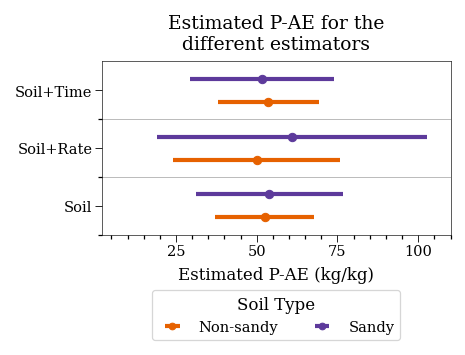

In [42]:
def plot_ate_groups(df, ax, count_col=None, mean_col="Mean", lowci_col="LowerCI", 
                    upci_col="UpperCI"):
    '''
    Makes a plot to compare the ATE estimates. The index must have two levels,
    being level_0 the group/model name, and level_1 the soil type. 
    '''
    for soil in ('Non-sandy', 'Sandy'):
        tmp_soil_df = df.loc[(slice(None), soil), :].reset_index(level=1)
        y = np.arange(len(tmp_soil_df)) - (0.2 if soil == 'Non-sandy' else -0.2)
        ax.errorbar(
            y=y,
            x=tmp_soil_df[mean_col],
            xerr=np.abs(tmp_soil_df[[lowci_col, upci_col]].values.T - tmp_soil_df[mean_col].values),
            fmt='o', label=soil, linewidth=2, markersize=4
        )
        if count_col is not None:
            for n, cluster in enumerate(tmp_soil_df.index):
                ax.text(
                    tmp_soil_df.loc[cluster, upci_col], y[n], 
                    f' ({tmp_soil_df.loc[cluster, count_col]}) ',
                    ha='left', va='center', fontsize=7
                )
    ax.set_yticks(np.arange(len(tmp_soil_df)))
    ax.set_xlabel('ATE Estimate (kg/ha)')
    ax.set_yticklabels(tmp_soil_df.index)


fig, ax = plt.subplots(1, 1, figsize=(3, 1.5))
tmp_df = ate_df.loc[(slice(None), slice('Non-sandy', 'Sandy')), :]
# tmp_df['count'] = 3
plot_ate_groups(tmp_df, ax,)

ax.set_xlabel('Estimated P-AE (kg/kg)')

# ax.set_title('Sample N-AE from\nthe different estimators')
# ax.axvline(cf_estimator.ate(X) * maize_std/100, color='k', linestyle='--', label='ATE')
ax.legend(title='Soil Type',loc='upper left', facecolor='none')
ax.set_title('Estimated P-AE for the\ndifferent estimators')
y = ax.get_yticks()
ax.set_yticks(y)
ax.set_yticks(y-.5, minor=True)
ax.grid(which='minor', axis='y', linestyle='-')
ax.grid(which='major', axis='y', linewidth=0)
ax.set_xticks(np.arange(0, 120, 5), minor=True)
ax.set_xticks(np.arange(0, 120, 25), minor=False)
ax.set_ylim(-0.5, 2.5)
ax.set_xlim(2, 110)
ax.legend(
    loc='lower center', bbox_to_anchor=(0.5, -.65, 0., .0), ncol=2, 
    title='Soil Type'
)

In [43]:
cluster_count_soil = cluster_count_soil.reset_index()
cluster_count_soil['soil_sandy'] = np.where(
    cluster_count_soil.soil_sandy > 0, 'Sandy', "Non-sandy"
)
cluster_count_soil = cluster_count_soil.set_index(['Cluster name', 'soil_sandy'])

CATE Intercept Results:  No intercept was fitted!


point_estimate  stderr  zstat  pvalue  ci_lower  \
Basal-Only Non-sandy          56.346   9.688  5.816   0.000    37.358   
           Sandy              57.312  12.228  4.687   0.000    33.345   
Top-Only   Non-sandy          44.773  12.499  3.582   0.000    20.275   
           Sandy              14.833  30.165  0.492   0.623   -44.290   

                      ci_upper  count  
Basal-Only Non-sandy    75.334    486  
           Sandy        81.279    237  
Top-Only   Non-sandy    69.270    152  
           Sandy        73.956     37

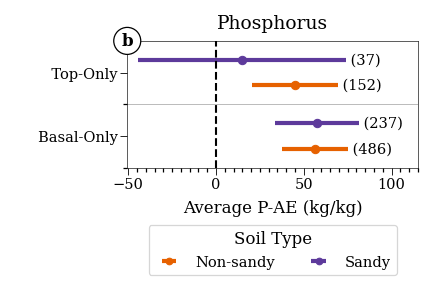

In [44]:
def get_coefs_df_from_summary(est, feature_names):
    coefs_df = pd.read_html(
        est.summary(feature_names=feature_names).tables[0].as_html()
        , header=0, index_col=0
    )[0]
    coefs_df.index = coefs_df.index.map(
        lambda x: tuple(x.split('_')[::-1])
    )
    return coefs_df

timing_coefs = get_coefs_df_from_summary(lineardml_soil_time, x_names_time)
cluster_order = [
    'Basal-Only', 'Top-Only'
]

timing_coefs = timing_coefs.loc[cluster_order, :]
tmp_df = timing_coefs.copy() # Convert to N-AE
tmp_df['count'] = cluster_count_soil.loc[timing_coefs.index]

# fig, ax = plt.subplots(1, 1, figsize=(2.5, 3.5))
fig, ax = plt.subplots(1, 1, figsize=(2.5, 1.1))
plot_ate_groups(
    tmp_df, ax, count_col='count', mean_col='point_estimate', 
    lowci_col='ci_lower', upci_col='ci_upper'
)
ax.text(
    0, 1, 'b', transform=ax.transAxes, va='center', ha='center', fontsize=8,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
)
ax.set_title('Phosphorus')
ax.set_xlabel('Average P-AE (kg/kg)')

ax.axvline(0, color='k', linestyle='--')
y = ax.get_yticks()
ax.set_yticks(y)
ax.set_yticks(y-.5, minor=True)
ax.grid(which='minor', axis='y', linestyle='-')
ax.grid(which='major', axis='y', linewidth=0)
ax.set_ylim(-.5, 1.5)
ax.set_xticks(np.arange(-50, 120, 5), minor=True)
ax.set_yticklabels([f'{i:>15}' for i in cluster_order])
ax.legend(
    loc='lower center', bbox_to_anchor=(0.5, -.9, 0., .0), ncol=2, 
    title='Soil Type'
)
# ax.set_title("Effect of N-fertilizer for\ndifferent application strategies")

fig.savefig(f'{DATA_PATH}/results/figures/P-fertilizer-timing-effects.pdf', bbox_inches='tight', dpi=300)
tmp_df

## Non-spatial variance

In [45]:
T_absolute = data.loc[transformed_data_pstrimmed.index, treatment_name].to_numpy()
Y_absolute = data.loc[transformed_data_pstrimmed.index, outcome_name].to_numpy()

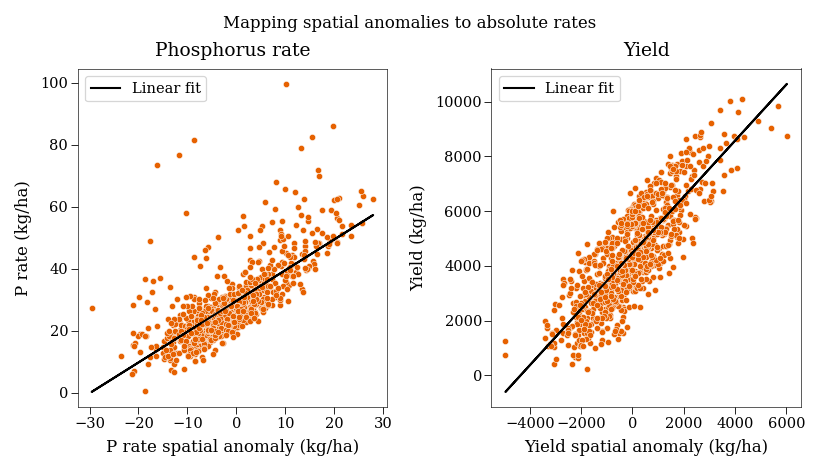

In [46]:
from statsmodels.api import OLS, add_constant

# A model to map spaital anomalies to absolute rates
fertilizer_anomaly_to_absolute = OLS(
    endog=T_absolute,
    exog=add_constant(T)
).fit()

yield_anomaly_to_absolute = OLS(
    endog=Y_absolute,
    exog=add_constant(Y)
).fit()

fig, axes = plt.subplots(1, 2, figsize=(5.5, 3))

ax = axes[0]
sns.scatterplot(x=T, y=T_absolute, ax=ax)
ax.set_xlabel('P rate spatial anomaly (kg/ha)')
ax.set_ylabel('P rate (kg/ha)')
ax.plot(
    T, fertilizer_anomaly_to_absolute.predict(add_constant(T)), 
    color='k', linestyle='-', label='Linear fit'
)
plt.tight_layout()
ax.set_title('Phosphorus rate')
ax.legend()

ax = axes[1]
sns.scatterplot(x=Y, y=Y_absolute, ax=ax)
ax.set_xlabel('Yield spatial anomaly (kg/ha)')
ax.set_ylabel('Yield (kg/ha)')
ax.plot(
    Y, yield_anomaly_to_absolute.predict(add_constant(Y)), 
    color='k', linestyle='-', label='Linear fit'
)
plt.tight_layout()
ax.set_title('Yield')
ax.legend()

fig.suptitle('Mapping spatial anomalies to absolute rates', y=1.02)

fertilizer_anomaly_to_absolute.rsquared, yield_anomaly_to_absolute.rsquared

Around 60% of the yield and nitrogen rates is not explained by spatial patterns. 

## Variable rate response

In [47]:
t_grid = np.linspace(np.percentile(T, 2.5), np.percentile(T, 97.5), 100)
t_absolute_grid = fertilizer_anomaly_to_absolute.predict(add_constant(t_grid))

def plot_response_curve(est, ax, X=None, ci=True, kwargs_line={}, kwargs_ci={},
                        t_grid=None):
    lift_inference = []
    if t_grid is None: 
        t_grid = np.linspace(np.percentile(T, 2.5), np.percentile(T, 97.5), 100)
    if isinstance(est, LinearDML):
        for t in t_grid: 
            if ci:
                ate_inf = est.ate_inference(X=X, T0=T0, T1=t)
                lift_inference.append((ate_inf.mean_point, *ate_inf.conf_int_mean()))
            else:
                lift_inference.append([est.ate(X=X, T0=0, T1=t)])
    elif est.shape[0] == 3:
        lift_inference = est.T
    else:
        lift_inference = est.reshape(-1, 1)      
    lift_inference = np.array(lift_inference)
    
    t_grid_ = t_grid 
    lift_inference_ = lift_inference

    sns.lineplot(
        x=t_grid_, y=lift_inference_[:, 0], ax=ax,
        **kwargs_line
    )
    if ci:
        if not kwargs_ci:
            kwargs_ci=dict(alpha=.1)
        ax.fill_between(
            x=t_grid_, y1=lift_inference_[:,1], 
            y2=lift_inference_[:,2], **kwargs_ci
        )
    ax.set_xlabel('P-Fertilizer rate (kg/ha)')
    ax.set_ylabel('Yield (kg/ha)')

In [48]:
t_grid = np.linspace(np.percentile(T_absolute, 2.5), np.percentile(T_absolute, 97.5), 100)
lift_inference_rate = {
    'All': np.zeros(shape=(3, len(t_grid))),
    'Non-sandy': np.zeros(shape=(3, len(t_grid))),
    'Sandy': np.zeros(shape=(3, len(t_grid)))
}
for n, t in enumerate(t_grid): 
    ate_inf = rate_inference(X_soil, T0=T0, T1=t, y_offset=spatial_y)
    lift_inference_rate['All'][:, n] = (ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper'])
    ate_inf = rate_inference(X_soil[X_soil[:, 1]==0], T0=T0, T1=t, y_offset=spatial_y)
    lift_inference_rate['Non-sandy'][:, n] = (ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper'])
    ate_inf = rate_inference(X_soil[X_soil[:, 1]==1], T0=T0, T1=t, y_offset=spatial_y)
    lift_inference_rate['Sandy'][:, n] = (ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper'])

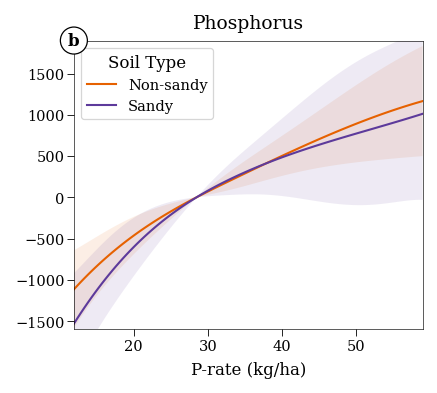

In [49]:
fig, ax =plt.subplots(1, 1, figsize=(3, 2.5))
plot_response_curve(
    lift_inference_rate['Non-sandy'], ax, X=X_soil[X_soil[:,0].astype(bool)],
    kwargs_line=dict(label='Non-sandy'), t_grid=t_grid
)
plot_response_curve(
    lift_inference_rate['Sandy'], ax, X=X_soil[X_soil[:,1].astype(bool)],
    kwargs_line=dict(label='Sandy'), t_grid=t_grid
)

ax.set_title('Average P-fertilizer response')

ax.set_xlabel('P-rate (kg/ha)')
ax.set_title('Phosphorus')
ax.legend(loc='upper left', title='Soil Type')
ax.text(
    0, 1, 'b', transform=ax.transAxes, va='center', ha='center', fontsize=8,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k'), zorder=6
)
# ax.set_yticks(np.arange(-1600, 2500, 500))
# ax.set_yticks(np.arange(-1600, 2500, 100), minor=True)
ax.grid(which='minor', linestyle=':')
# ax.set_ylabel('Change in yield compared to using\nthe average fertilizer rate (kg/ha)')
ax.set_ylabel('')
ax.set_ylim(-1600, 1900)
ax.set_xlim(t_grid.min(), t_grid.max())

# ax.set_xlim(0, 100*T.max())
fig.savefig(f'{DATA_PATH}/results/figures/P-fertilizer-dose-response-curve.pdf', bbox_inches='tight', dpi=300)
# fig.savefig(f'{DATA_PATH}/results/figures/poster/P-fertilizer-dose-response-curve.png', bbox_inches='tight', dpi=1200)

In [50]:
# The spatial average of the treatment
spatial_t_mean_sand = pd.DataFrame([
    spatial_t, X_soil[:, 1] 
]).T.groupby(1).mean().iloc[:, 0]
spatial_t_mean_sand.index = ['Non-sandy', 'Sandy']
spatial_t_mean_sand.name = 'P spatial mean'
spatial_t_mean_sand

Non-sandy    30.088361
Sandy        31.033526
Name: P spatial mean, dtype: float64

In [51]:
t25, t75

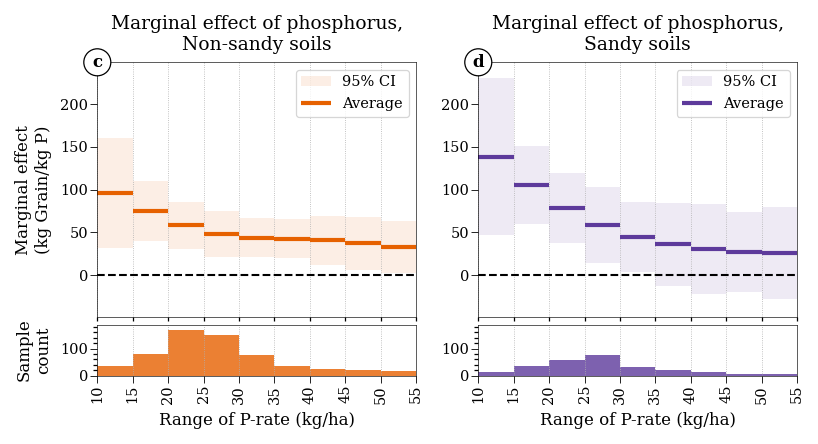

In [52]:
# Marginal response for amount ranges
cycle_colors = [i['color'] for i in plt.rcParams['axes.prop_cycle']]
step_size = 5
fig, axes = plt.subplots(2, 2, figsize=(5.5, 3), sharey=False, sharex=False, height_ratios=[5, 1])

x_ = np.arange(10, 60, step_size)
x = np.arange(10, 60, step_size)
x_ = x 
lift_amount_df = pd.DataFrame(
    columns=pd.MultiIndex.from_tuples([
        ('Non-sandy', 'Mean'), ('Non-sandy', 'LowerCI'), ('Non-sandy', 'UpperCI'),
        ('Sandy', 'Mean'), ('Sandy', 'LowerCI'), ('Sandy', 'UpperCI')
    ]), index=x_[:-1]
)
for n, soil in enumerate(('Non-sandy', 'Sandy')):
    ax = axes[0][n]
    ax2 = axes[1][n]
    ax.axhline(0, color='k', linestyle='--')
    lift_inference = []
    for i, t in enumerate(x[:-1]):
        t1 = x[i+1]
        ate_inf = rate_inference(X=X_soil[X_soil[:, n].astype(bool)],  T0=t, T1=t1)
        lift_inference.append(
            np.array([ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper']])/(t1 - t)
        )
        lift_amount_df.loc[t, (soil, slice(None))] = lift_inference[-1]
        T_ = T_absolute[X_soil[:, n].astype(bool)]
        # ax.text(
        #     x_[i] + (x_[i+1] - x_[i])/2, lift_inference[-1][2]+1, f'({((T_ >= t) & (T_ < t1)).sum()})', 
        #     ha='center', fontsize=7
        # )
        ax.fill_between(
            x=[x_[i], x_[i+1]], y1=lift_inference[-1][1], y2=lift_inference[-1][2],
            alpha=0.1, color=cycle_colors[n], linewidth=0, label='95% CI' if i==0 else None
        )

        ax2.fill_between(
            x=[x_[i], x_[i+1]], y1=0, y2=((T_ >= t) & (T_ < t1)).sum(),
            alpha=.8, color=cycle_colors[n], linewidth=0, label='95% CI' if i==0 else None
        )
    lift_inference = np.array(lift_inference)
    err = np.abs(lift_inference[:, 1:] - lift_inference[:, 0].reshape(-1, 1)).T 
    ax.hlines(
        y=lift_inference[:, 0], xmin=x_[:-1], xmax=x_[1:], linewidth=2,
        label='Average', color=cycle_colors[n]
    )
    if n == 0: ax.set_ylabel('Marginal effect\n(kg Grain/kg P)')
    ax.set_xticks(x_[:])
    # ax.set_yticks(np.arange(-50, 100, 2), minor=True)
    ax.grid(which='major', linestyle=':', axis='x')
    # ax.grid(which='minor', linestyle='-')
    ax.set_ylim(-49, 249)
    ax.set_xlim(x_[0], x_[-1])
    ax.set_title(f'Marginal effect of phosphorus,\n{soil} soils')
    ax.text(
        0, 1, ('c', 'd')[n], transform=ax.transAxes, va='center', ha='center', fontsize=8,
        fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
    )
    ax.set_xticks(ax.get_xticks(), minor=True)
    ax.set_xticks([], minor=False)
    ax.grid(which='minor', linestyle=':', axis='x')
    # ax.set_xticks([-900, 900], minor=False)
    ax.legend(loc='upper right')
    # Histplot
    ax2.set_ylim(0, 189)
    ax2.set_xticks(x_[:])
    ax2.set_xlim(x_[0], x_[-1])
    ax2.set_yticks(np.arange(0, 190, 20), minor=True)
    ax2.grid(which='major', linestyle=':', axis='x')
    # ax2.grid(which='minor', linestyle='-')
    ax2.set_xticklabels([f'{x_[i]:.0f}' for i, _ in enumerate(x_[:])], rotation=90)
    ax2.set_xlabel('Range of P-rate (kg/ha)')
    # ax2.yaxis.tick_right()
    # ax2.yaxis.set_label_position("right")
    if n == 0: ax2.set_ylabel('Sample\ncount',)
plt.tight_layout()
plt.subplots_adjust(hspace=.05)


# fig.suptitle(f'Average marginal effect of N Fertilizer for\ngiven  {step_size} kg/ha N fertilizer ranges', y=1.05)
fig.savefig(f'{DATA_PATH}/results/figures/P-fertilizer-marginal-dose-response.pdf', bbox_inches='tight', dpi=300)
lift_amount_df['Fertilizer rate'] = lift_amount_df.index + T_absolute.mean()
lift_amount_df.style.format(precision=1)

# Benchmark models

The benchmark models are used to compare our approach. Two benchmarks will be used: regular causal Linear OLS, and Predictive ML

## Causal OLS

In [53]:
from statsmodels.api import OLS

In [54]:
# OLS model for homogeneous effect
ols_data = transformed_data_pstrimmed[dml_soil_features].copy()
ols_data[outcome_name] = demeaned_outcome
ols_data[treatment_name] = demeaned_treatment
ols_data = ols_data.join([
    (ols_data[treatment_name] * 
        (ols_data['soil_sandy'].astype(bool))).rename('N_sandy'),
    (ols_data[treatment_name] * 
        (~ols_data['soil_sandy'].astype(bool))).rename('N_nosandy')
])
ols_data = ols_data.drop(columns=treatment_name)
ols_model_hom = OLS(
    endog=ols_data[outcome_name],
    exog=ols_data.drop(columns=[outcome_name])
).fit().summary()
pd.read_html(
    ols_model_hom.tables[1].as_html()
    , header=0, index_col=0
)[0].loc[['N_sandy', 'N_nosandy']]

,coef,std err,t,P>|t|,[0.025,0.975]
N_sandy,54.6743,10.861,5.034,0.0,33.355,75.993
N_nosandy,42.3444,7.464,5.673,0.0,27.694,56.995


## Predictive ML

In [55]:
from sklearn.base import clone
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
# A RF with PDP to simulate the effect of fertilizer on yield
# This article was just released and it uses PDP: https://www.sciencedirect.com/science/article/pii/S1161030125004216
# X_rf_response = np.hstack([W, T.reshape(-1, 1)])

data_ml_pred = data.copy() # This uses all data, so the effect identification phase is skipped
data_ml_pred = data_ml_pred.drop(columns=['crop_name', 'crop_maize', 'outcome_prodstd'])
data_ml_pred = data_ml_pred.loc[transformed_data_pstrimmed.index]
# data_ml_pred[treatment_name] = demeaned_treatment + spatial_t
# data_ml_pred[outcome_name] = demeaned_outcome + spatial_y
X_rf_response = data_ml_pred.drop(columns=[outcome_name])
Y_rf_response = data_ml_pred[outcome_name]
model_rf_response = clone(model_q)
y_cv_pred = cross_val_predict(
    model_rf_response,
    X_rf_response,
    Y_rf_response,
)
model_rf_response = model_rf_response.fit(X_rf_response, Y_rf_response)
r2_score(Y_rf_response, y_cv_pred)

In [56]:
pd.Series(
    model_rf_response.feature_importances_,
    index=X_rf_response.columns
).sort_values(ascending=False).head(10)

fertP_total                0.097052
fertN_total                0.091210
soilfert_cec               0.047276
0to100perc_season_tmean    0.037620
soilfert_oc                0.034772
20to30perc_season_tmean    0.030931
elevation_value            0.028291
soilpp_sand                0.027981
0to10perc_season_tmean     0.026954
50to60perc_season_tmean    0.024301
dtype: float64

In [57]:
X_rf_response_t0 = X_rf_response.copy()
X_rf_response_t1 = X_rf_response.copy()

X_rf_response_t0[treatment_name] = t25
X_rf_response_t1[treatment_name] = t75

model_rf_ite = (
    model_rf_response.predict(X_rf_response_t1) - model_rf_response.predict(X_rf_response_t0)
)/X_rf_response_t1[treatment_name]
model_rf_ite = model_rf_ite.to_frame()
model_rf_ite.describe()

,fertP_total
count,912.000000
mean,7.941506
std,2.285568
min,0.953579
25%,6.279710
50%,7.902658
75%,9.410438
max,14.602670


In [58]:
rf_response_pdp = partial_dependence(
    model_rf_response, X_rf_response, features=[treatment_name],
    kind='individual'
)

# model_rf_response.predict(X_rf_response)

In [59]:
rf_response_df_sandy = {}
rf_response_df_nonsandy = {}
rf_response_df = {}
X_rf_response_t0 = X_rf_response.copy()
X_rf_response_t0[treatment_name] = T_absolute.mean()
for t in t_grid:
    X_rf_response_t1 = X_rf_response.copy()
    X_rf_response_t1[treatment_name] = t
    rf_response_df[t] = model_rf_response.predict(X_rf_response_t1) - model_rf_response.predict(X_rf_response_t0)
    rf_response_df_sandy[t] = model_rf_response.predict(X_rf_response_t1.loc[X_rf_response_t1['soil_sandy']]) - \
        model_rf_response.predict(X_rf_response_t0.loc[X_rf_response_t0['soil_sandy']])
    rf_response_df_nonsandy[t] = model_rf_response.predict(X_rf_response_t1.loc[~X_rf_response_t1['soil_sandy']]) - \
        model_rf_response.predict(X_rf_response_t0.loc[~X_rf_response_t0['soil_sandy']])
rf_response_df_sandy = pd.DataFrame(rf_response_df_sandy)
rf_response_df_sandy = pd.melt(rf_response_df_sandy)
rf_response_df_nonsandy = pd.DataFrame(rf_response_df_nonsandy)
rf_response_df_nonsandy = pd.melt(rf_response_df_nonsandy)
rf_response_df = pd.DataFrame(rf_response_df)
rf_response_df = pd.melt(rf_response_df)

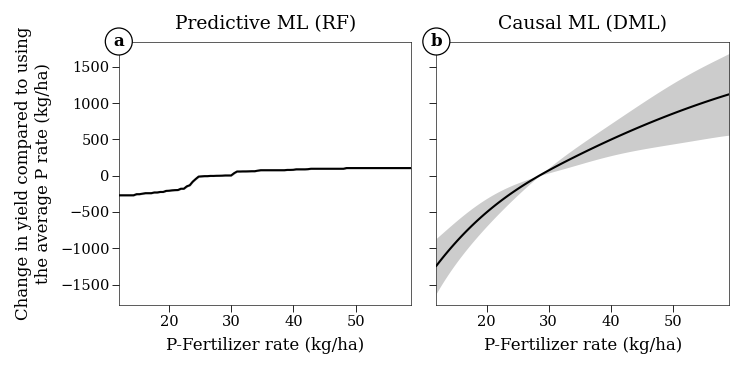

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharex=True, sharey=True)
ax = axes[0]
sns.lineplot(
    rf_response_df,
    x='variable',
    y='value',
    errorbar='se', ax=ax,
    color='k'
)
ax.set_xlabel('P-Fertilizer rate (kg/ha)')
ax.set_ylabel('Change in yield compared to using\nthe average P rate (kg/ha)')
ax.set_title('Predictive ML (RF)')
ax.set_xlim(t_grid.min(), t_grid.max())

ax = axes[1]
plot_response_curve(
    lift_inference_rate['All'], ax, kwargs_ci=dict(alpha=.2, color='k', linewidth=0), 
    t_grid=t_grid, kwargs_line=dict(color='k')
)
ax.set_title('Causal ML (DML)')
ax.set_xlabel('P-Fertilizer rate (kg/ha)')
ax.set_xlim(t_grid.min(), t_grid.max())

for n, ax in enumerate(axes):
    ax.text(
        0, 1, ('a', 'b')[n], transform=ax.transAxes, va='center', ha='center', fontsize=8,
        fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
    )

# ax.set_xlim(0, 100*T.max())
fig.savefig(f'{DATA_PATH}/results/figures/P-fertilizer-predictive-vs-causal.pdf', bbox_inches='tight', dpi=300)
plt.tight_layout()

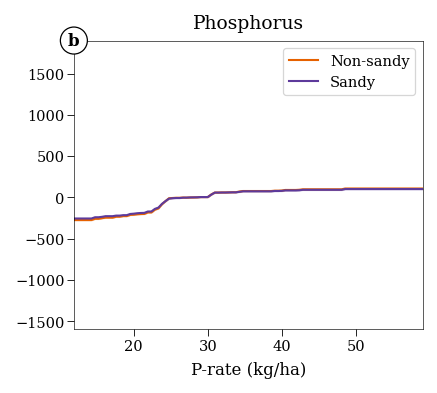

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5), sharex=True, sharey=True)
sns.lineplot(
    rf_response_df_nonsandy,
    x='variable',
    y='value',
    errorbar='se', ax=ax,
    color=cycle_colors[0], label='Non-sandy'
)
sns.lineplot(
    rf_response_df_sandy,
    x='variable',
    y='value',
    errorbar='se', ax=ax,
    color=cycle_colors[1], label='Sandy'
)
ax.set_xlabel('P-rate (kg/ha)')
ax.set_title('Phosphorus')
ax.set_xlim(t_grid.min(), t_grid.max())
ax.set_ylim(-1600, 1900)
ax.text(
    0, 1, 'b', transform=ax.transAxes, va='center', ha='center', fontsize=8,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
)
# ax.set_ylabel('Change in yield compared to using\nthe average nutrient rate (kg/ha)')
ax.set_ylabel('')
# ax.set_xlim(0, 100*T.max())
fig.savefig(f'{DATA_PATH}/results/figures/P-fertilizer-predictive.pdf', bbox_inches='tight', dpi=300)
fig.savefig(f'{DATA_PATH}/results/figures/poster/P-fertilizer-predictive.png', bbox_inches='tight', dpi=1200)

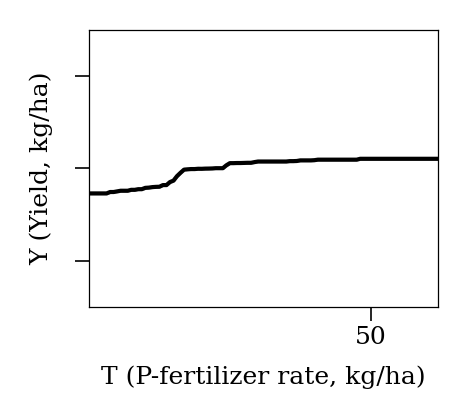

In [62]:
fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.2), dpi=300)
sns.lineplot(
    rf_response_df,
    x='variable',
    y='value',
    errorbar='se', ax=ax,
    color='k'
)
ax.set_ylim(-1500, 1500)

ax.set_yticklabels([])
ax.set_ylabel('Y (Yield, kg/ha)', fontsize=6)
ax.set_xlabel('T (P-fertilizer rate, kg/ha)', fontsize=6)
ax.set_xticks(np.arange(0, t_grid.max(), 50))
ax.set_xlim(t_grid.min(), t_grid.max())
ax.set_xticklabels(ax.get_xticklabels(), fontsize=6)
fig.savefig(f'{DATA_PATH}/results/figures/all-P-fertilizer-dose-response-predictive.svg', bbox_inches='tight', dpi=300, transparent=True)
fig.savefig(f'{DATA_PATH}/results/figures/poster/all-P-fertilizer-dose-response-predictive.png', bbox_inches='tight', dpi=1500)

# Robustness checks

## Sensitivity analysis

In [63]:
lineardml_only_soil.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
===============================================
CI Lower Theta Lower Theta Theta Upper CI Upper
-----------------------------------------------
   31.04      43.743 52.92      62.098   74.901
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.255                   0.2
----------------------------------------------
"""

In [64]:
lineardml_soil_time.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
================================================
CI Lower Theta Lower Theta  Theta Upper CI Upper
------------------------------------------------
  31.318      43.955 53.119      62.283   75.024
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.256                 0.202
----------------------------------------------
"""

## Placebo test

In [65]:
from tqdm import tqdm

In [66]:
# Run placebo for the Timing and Amount heterogeneous estimators
placebo_coefs_estimates_dict = {
    'Soil': [],
    'Soil+Rate': [],
    'Soil+Time': [],
}
# placebo_coefs_estimates_dict['Amount rate'] = []
placebo_rate_response = []

N_PLACEBO_RUNS = 0
if N_PLACEBO_RUNS < 1:
    with open(f'{DATA_PATH}/results/robustness-checks/P-response-placebo', 'rb') as f:
        placebo_coefs_estimates_dict, placebo_rate_response = pickle.load(f)

# placebo_coefs_estimates_dict['Soil+Rate'] = []
# placebo_rate_response = []
# N_PLACEBO_RUNS = 100

for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T_absolute, size=len(T_absolute), replace=True)
    # Heterogeneous by soil and amount
    lineardml_amount_placebo = LinearDML(
        model_y=model_q, 
        model_t=MultiOutputRegressor(model_treatment), 
        treatment_featurizer=treatment_featurizer,
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_amount_placebo = lineardml_amount_placebo.fit(
        Y=Y, T=T_placebo.reshape(-1, 1), W=W_soil, X=X_soil,
        inference='statsmodels', cache_values=True,
    )
    placebo_df = pd.DataFrame([
        list(rate_inference(
            X_soil[X_soil[:, 0] == 1], est=lineardml_amount_placebo, 
            T0=t25, T1=t75, y_offset=0, scale=(t75-t25)
        ).values()),
        list(rate_inference(
            X_soil[X_soil[:, 1] == 1], est=lineardml_amount_placebo,  
            T0=t25, T1=t75, y_offset=0, scale=(t75-t25)
        ).values())
    ], columns=['point_estimate', 'stderr', 'ci_lower', 'ci_upper', 'pvalue'], index=['Non-sandy', 'Sandy'])
    placebo_coefs_estimates_dict['Soil+Rate'].append(placebo_df)
    placebo_rate_response.append(
        np.array([
            lineardml_amount_placebo.ate(X_soil, T0=T0, T1=i) 
            for i in t_grid
        ])
    )

0it [00:00, ?it/s]


In [67]:
for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Heterogeneous by Soil and time
    lineardml_time_placebo = LinearDML(
        model_y=model_q,
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_time_placebo = lineardml_time_placebo.fit(
        Y=Y, T=T_placebo, W=W_soil_time, X=X_soil_time,
        inference='statsmodels', cache_values=True,
    )
    placebo_coefs_estimates_dict['Soil+Time'].append(
        get_coefs_df_from_summary(lineardml_time_placebo, x_names_time)
    )

0it [00:00, ?it/s]


In [68]:
for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Heterogeneous by Soil only
    lineardml_soil_placebo = LinearDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_soil_placebo = lineardml_soil_placebo.fit(
        Y=Y, T=T_placebo, W=W_soil, X=X_soil,
        inference='statsmodels', cache_values=True,
    )
    placebo_coefs_estimates_dict['Soil'].append(
        get_coefs_df_from_summary(lineardml_soil_placebo, x_names_soil)
    )

0it [00:00, ?it/s]


In [69]:
with open(f'{DATA_PATH}/results/robustness-checks/P-response-placebo', 'wb') as f:
    pickle.dump((placebo_coefs_estimates_dict, placebo_rate_response), f)

In [70]:
def get_placebo_results(list_df_coefs):
    tmp_df = pd.concat(list_df_coefs)
    levels = list(range(tmp_df.index.nlevels))
    point_estimate = tmp_df.groupby(level=levels).point_estimate.mean()
    stderr = tmp_df.groupby(level=levels).point_estimate.agg(lambda x: np.sqrt((x**2).mean()))
    pvalue = tmp_df.groupby(level=levels).point_estimate.agg(
        lambda x: 2*min((x >= 0).mean(), (x < 0).mean())
    )
    tmp_df = pd.concat([point_estimate.to_frame(), stderr.to_frame(), pvalue.to_frame()], axis=1)
    tmp_df.columns = ['point_estimate', 'stderr', 'pvalue'] 
    return tmp_df

placebo_results_df = []
for est, list_df_coefs in placebo_coefs_estimates_dict.items():
    tmp_df = get_placebo_results(list_df_coefs)
    tmp_df['est'] = est
    tmp_df = tmp_df.reset_index()
    if 'index' in tmp_df.columns:
        tmp_df = tmp_df.rename(columns={'index': 'level_1'})
    placebo_results_df.append(tmp_df)
placebo_results_df = pd.concat(placebo_results_df)
placebo_results_df = placebo_results_df.set_index(['est', 'level_0', 'level_1'])
placebo_results_df.index = placebo_results_df.index.reorder_levels([0, 2, 1])
placebo_results_df = placebo_results_df.sort_index()

In [71]:
placebo_results_df

point_estimate     stderr  pvalue
est       level_1   level_0                                    
Soil      Non-sandy NaN             0.067360   7.088247    1.00
          Sandy     NaN            -0.194860  10.032798    0.96
Soil+Rate Non-sandy NaN            -3.090966  11.433321    0.74
          Sandy     NaN            -5.633787  16.065338    0.72
Soil+Time Non-sandy Basal          -0.905860   7.698857    1.00
                    No Basal       -0.074920  12.442739    0.96
          Sandy     Basal          -0.497030   9.601679    0.96
                    No Basal       -0.221560  27.859223    0.98

In [72]:
print(placebo_results_df.astype(float).round(3).to_latex())

\begin{tabular}{lllrrr}
\toprule
 &  &  & point_estimate & stderr & pvalue \\
est & level_1 & level_0 &  &  &  \\
\midrule
\multirow[t]{2}{*}{Soil} & Non-sandy & NaN & 0.067000 & 7.088000 & 1.000000 \\
\cline{2-6}
 & Sandy & NaN & -0.195000 & 10.033000 & 0.960000 \\
\cline{1-6} \cline{2-6}
\multirow[t]{2}{*}{Soil+Rate} & Non-sandy & NaN & -3.091000 & 11.433000 & 0.740000 \\
\cline{2-6}
 & Sandy & NaN & -5.634000 & 16.065000 & 0.720000 \\
\cline{1-6} \cline{2-6}
\multirow[t]{4}{*}{Soil+Time} & \multirow[t]{2}{*}{Non-sandy} & Basal & -0.906000 & 7.699000 & 1.000000 \\
 &  & No Basal & -0.075000 & 12.443000 & 0.960000 \\
\cline{2-6}
 & \multirow[t]{2}{*}{Sandy} & Basal & -0.497000 & 9.602000 & 0.960000 \\
 &  & No Basal & -0.222000 & 27.859000 & 0.980000 \\
\cline{1-6} \cline{2-6}
\bottomrule
\end{tabular}



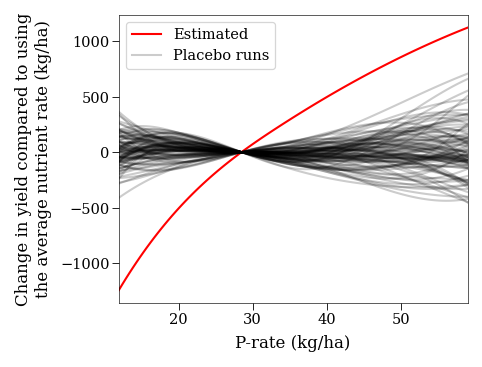

In [73]:
fig, ax =plt.subplots(1, 1, figsize=(3, 2.5))
plot_response_curve(
    lift_inference_rate['All'], ax, ci=False, 
    kwargs_line=dict(label='Estimated', color='r'), t_grid=t_grid
)

# placebo_t_grid = np.quantile(T, np.linspace(0.025, 0.975, 100))

for est in placebo_rate_response:
    plot_response_curve(
        est, ax, ci=False, kwargs_line=dict(color='k', alpha=.2),
        X=X_soil, t_grid=t_grid
    )
plot_response_curve(
    est, ax, ci=False, kwargs_line=dict(color='k', alpha=.2, label='Placebo runs'),
    X=X_soil, t_grid=t_grid
)

# ax.set_title('Average N-fertilizer response')
ax.set_xlim(t_grid.min(), t_grid.max())
ax.set_ylabel('Change in yield compared to using\nthe average nutrient rate (kg/ha)')
ax.set_xlabel('P-rate (kg/ha)')

# ax.set_xlim(0, 100*T.max())
ax.legend()
fig.savefig(f'{DATA_PATH}/results/figures/P-fertilizer-dose-response-curve-placebo.pdf', bbox_inches='tight', dpi=300)

# Analysis for publication

## Test difference between soil groups

In [74]:
# Create a DataFrame to store the difference in effects test results
diff_test_results = pd.DataFrame(
    columns=['Mean Difference (Non-sandy - Sandy)', 'SE Difference', 'Z-statistic', 'P-value']
)


def z_test_diff_means(mean1, mean2, se1, se2):
    diff_mean = mean1 - mean2
    se_diff = np.sqrt(se1**2 + se2**2)
    # Calculate the Z-statistic
    if se_diff != 0:
        z_statistic = diff_mean / se_diff
        p_value = 2 * stats.norm.sf(np.abs(z_statistic))
    else:
        z_statistic = np.nan
        p_value = np.nan # Or 1.0 if diff_mean is also 0, but nan is safer for general case
    return z_statistic, p_value

from itertools import combinations
def pairwise_ztest(df, grouping_col, compare_col, mean_col, se_col):
    out_df = []
    for g in df[grouping_col].unique():
        tmp_df = df.loc[df[grouping_col] == g].set_index(compare_col)
        # print(tmp_df)
        for g1, g2 in combinations(tmp_df.index, 2):
            if g1 == g2:
                continue
            mean1 = tmp_df.loc[g1, mean_col]
            mean2 = tmp_df.loc[g2, mean_col]
            se1 = tmp_df.loc[g1, se_col]
            se2 = tmp_df.loc[g2, se_col]
            z_statistic, p_value = z_test_diff_means(mean1, mean2, se1, se2)
            out_df.append((
                g, g1, g2, mean1 - mean2, z_statistic, p_value
            ))
    out_df = pd.DataFrame(
        out_df, 
        columns=[grouping_col, 'Group1', 'Group2', 'Diff', 'Zstat', 'pvalue']
    )
    return pd.DataFrame(out_df).set_index([grouping_col, 'Group1', 'Group2']).sort_index()
tmp_df = ate_df.reset_index()
tmp_df = tmp_df.loc[tmp_df['Soil'] != 'ATE']
pairwise_ztest(tmp_df, 'Estimate', 'Soil', 'Mean', "SE")

,,,Diff,Zstat,pvalue
Estimate,Group1,Group2,,,
Soil,Non-sandy,Sandy,-1.383546,-0.098555,0.921492
Soil+Rate,Non-sandy,Sandy,-11.061811,-0.441165,0.659093
Soil+Time,Non-sandy,Sandy,2.013118,0.145361,0.884426


In [75]:
z_test_time = pairwise_ztest(timing_coefs.reset_index(), 'level_1', 'level_0', 'point_estimate', "stderr")
z_test_time

,,,Diff,Zstat,pvalue
level_1,Group1,Group2,,,
Non-sandy,Basal-Only,Top-Only,11.573,0.73182,0.464278
Sandy,Basal-Only,Top-Only,42.479,1.30507,0.191869


In [76]:
balance_cols = [
    'fieldsize_value', 'history_legume', 'history_maize',
    'history_maizelegume', 'history_nocrop', 'history_oilseed', 'history_rootandtuber',
    '0to100perc_season_prec', '0to100perc_season_rainydays',
    '0to100perc_season_srad', '0to100perc_season_tmean'
]

def smd_weighted(df, group_col, groups_to_compare=None, ignore_cols=None):
    """
    Computes the Standardized Mean Difference (SMD) between two groups in a DataFrame,
    using provided weights.

    Args:
        df (pd.DataFrame): The input DataFrame containing features, group assignments, and weights.
        group_col (str): The name of the column that defines the two groups.
                         This column must have exactly two unique non-NaN values.
        ignore_cols (list, optional): A list of column names to ignore when calculating SMD.
                                       These columns will not be treated as covariates.
                                       Defaults to None.

    Returns:
        pd.Series: A Series where the index is the feature name and values are their SMDs.
    """
    if ignore_cols is None:
        ignore_cols = []
    
    df_filtered = df.dropna(subset=[group_col]).copy()
    if groups_to_compare:
        df_filtered = df_filtered.loc[df_filtered[group_col].isin(groups_to_compare)]
    unique_groups = df_filtered[group_col].unique()
    if len(unique_groups) != 2:
        raise ValueError(
            f"The '{group_col}' column must contain exactly two unique groups after dropping NaNs. "
            f"Found: {unique_groups}"
        )

    if not groups_to_compare:
        group1_val, group2_val = df_filtered[group_col].unique()
    else:
        group1_val, group2_val = groups_to_compare
    df1 = df_filtered[df_filtered[group_col] == group1_val]
    df2 = df_filtered[df_filtered[group_col] == group2_val]
    covariate_cols = []
    for dtype in [np.number, bool]:
        covariate_cols.extend([
            col for col in df_filtered.select_dtypes(include=dtype).columns
            if col not in [group_col] + ignore_cols
        ])
    covariate_cols = list(pd.unique(covariate_cols))
    
    smd_results = {}

    for feat in covariate_cols:
        mean1 = df1[feat].mean()
        mean2 = df2[feat].mean()
        overall_std = df_filtered[feat].std()
        if overall_std == 0:
            smd = 0.0 
        else:
            smd = (mean1 - mean2) / overall_std
        smd_results[feat] = smd
    return pd.Series(smd_results)

def love_plot(df, ax, groups,  group_col='PFert_group',
              ref_line_loc=0.1):
    assert len(groups) == 2
    tmp_tmp_df = df.loc[df[group_col].isin(groups)].copy()
    smd_results = smd_weighted(
        tmp_tmp_df, group_col=group_col,
        ignore_cols=[treatment_name, outcome_name], groups_to_compare=groups
    )
    smd_results = smd_results.to_frame()
    smd_results.columns = ['Unbalanced']
    # Love Plot
    ax.axvline(0, color='k', linestyle='-')
    ax.axvline(ref_line_loc, color='gray', linestyle=':', linewidth=1)
    ax.axvline(-ref_line_loc, color='gray', linestyle=':', linewidth=1)
    sns.pointplot(
        smd_results.reset_index(), y='index', x='Unbalanced', markersize=4,
        linestyles='', ax=ax, color='w', markeredgecolor='k'
    )
  
    ax.set_xlabel('Standardized Mean Differences')
    ax.set_ylabel('')
    ax.grid(axis='y', linestyle='-')

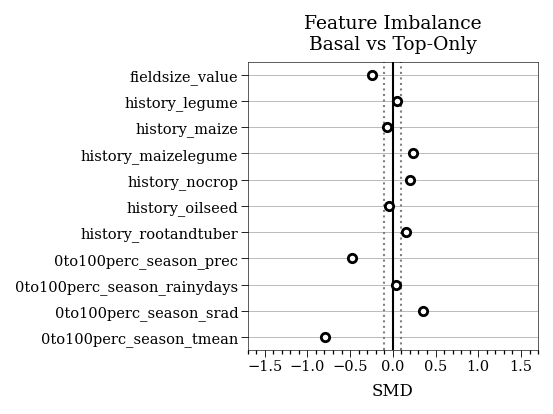

In [77]:
# Check balance in significantly different groups: Basal+Single vs Basal+Split
tmp_df = transformed_data_pstrimmed[balance_cols].copy()
tmp_df['group'] = appl_clusters_df['Cluster name']
tmp_df = tmp_df.loc[transformed_data_pstrimmed.soil_sandy == 1]


fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
love_plot(tmp_df, ax, groups=['Basal-Only', 'Top-Only'], group_col='group')
ax.set_title(f"Feature Imbalance\nBasal vs Top-Only")
ax.set_xticks(np.arange(-2, 2, 0.5))
ax.set_xticks(np.arange(-2, 2, 0.1), minor=True)

ax.set_xlabel('SMD')
ax.set_xlim(-1.7, 1.7)


In [78]:
z_test_time_soil = pairwise_ztest(timing_coefs.reset_index(), 'level_0', 'level_1', 'point_estimate', "stderr")
z_test_time_soil

,,,Diff,Zstat,pvalue
level_0,Group1,Group2,,,
Basal-Only,Non-sandy,Sandy,-0.966,-0.061920,0.950626
Top-Only,Non-sandy,Sandy,29.940,0.916943,0.359173


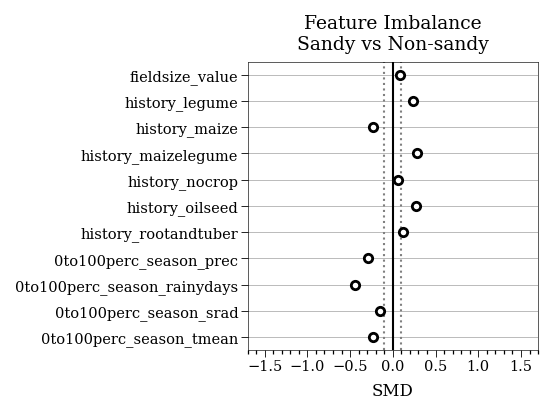

In [79]:
# Check balance in significantly different groups: Basal+Single vs Basal+Split
tmp_df = transformed_data_pstrimmed[balance_cols].copy()
tmp_df['group'] = np.where(transformed_data_pstrimmed.soil_sandy.astype(bool), "Sandy", "Non-sandy")

fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
love_plot(tmp_df, ax, groups=['Sandy', 'Non-sandy'], group_col='group')
ax.set_title(f"Feature Imbalance\nSandy vs Non-sandy")
ax.set_xticks(np.arange(-2, 2, 0.5))
ax.set_xticks(np.arange(-2, 2, 0.1), minor=True)

ax.set_xlabel('SMD')
ax.set_xlim(-1.7, 1.7)


In [80]:
est_order = ['Soil', 'Soil+Rate', 'Soil+Time']
ate_df.loc[(est_order, 'Sandy'), :].astype(float).round(1)

,,Mean,SE,LowerCI,UpperCI,pvalue
Estimate,Soil,,,,,
Soil,Sandy,53.9,11.6,31.1,76.7,0.0
Soil+Rate,Sandy,61.0,21.3,19.2,102.8,0.0
Soil+Time,Sandy,51.6,11.3,29.4,73.8,0.0


In [81]:
ate_df.loc[(est_order, 'ATE'), :].Mean.mean(), np.sqrt((ate_df.loc[(est_order, 'ATE'), :].astype(float).round(1).SE ** 2).mean())